1. Загрузка и чтение данных.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

Загружаем датасет с Goodle Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Читаем датасет и выводим информацию.

In [58]:
df = pd.read_csv('/content/drive/MyDrive/DARWIN.csv')
print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nИнформация о датасете:")
df.info()

Размер датасета: (174, 452)

Первые 5 строк:
     ID  air_time1  disp_index1  gmrt_in_air1  gmrt_on_paper1  \
0  id_1       5160     0.000013    120.804174       86.853334   
1  id_2      51980     0.000016    115.318238       83.448681   
2  id_3       2600     0.000010    229.933997      172.761858   
3  id_4       2130     0.000010    369.403342      183.193104   
4  id_5       2310     0.000007    257.997131      111.275889   

   max_x_extension1  max_y_extension1  mean_acc_in_air1  mean_acc_on_paper1  \
0               957              6601          0.361800            0.217459   
1              1694              6998          0.272513            0.144880   
2              2333              5802          0.387020            0.181342   
3              1756              8159          0.556879            0.164502   
4               987              4732          0.266077            0.145104   

   mean_gmrt1  ...  mean_jerk_in_air25  mean_jerk_on_paper25  \
0  103.828754  ...       

In [59]:
print("\nСтатистическое описание числовых признаков:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'ID' in numeric_cols:
    numeric_cols.remove('ID')
print(df[numeric_cols].describe())
print("\nУникальные классы:", df['class'].unique())
print("\nКоличество строк в каждом классе:")
print(df['class'].value_counts())


Статистическое описание числовых признаков:
           air_time1  disp_index1  gmrt_in_air1  gmrt_on_paper1  \
count     174.000000   174.000000    174.000000      174.000000   
mean     5664.166667     0.000010    297.666685      200.504413   
std     12653.772746     0.000003    183.943181      111.629546   
min        65.000000     0.000002     28.734515       29.935835   
25%      1697.500000     0.000008    174.153023      136.524742   
50%      2890.000000     0.000009    255.791452      176.494494   
75%      4931.250000     0.000011    358.917885      234.052560   
max    109965.000000     0.000028   1168.328276      865.210522   

       max_x_extension1  max_y_extension1  mean_acc_in_air1  \
count        174.000000        174.000000        174.000000   
mean        1977.965517       7323.896552          0.416374   
std         1648.306365       2188.290512          0.381837   
min          754.000000        561.000000          0.067748   
25%         1362.500000       6124.0

2. Визуализируем данные.

Скрипичный график:

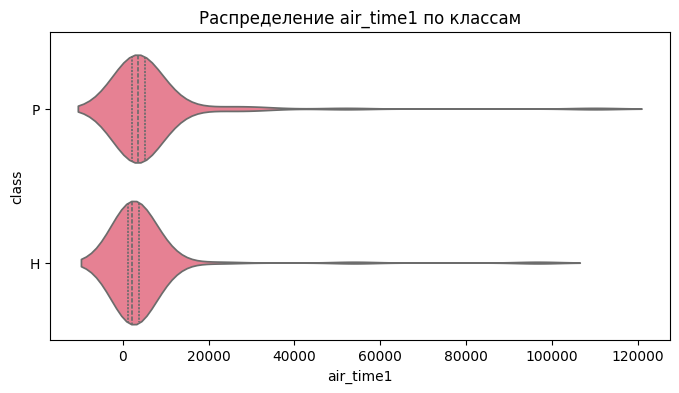

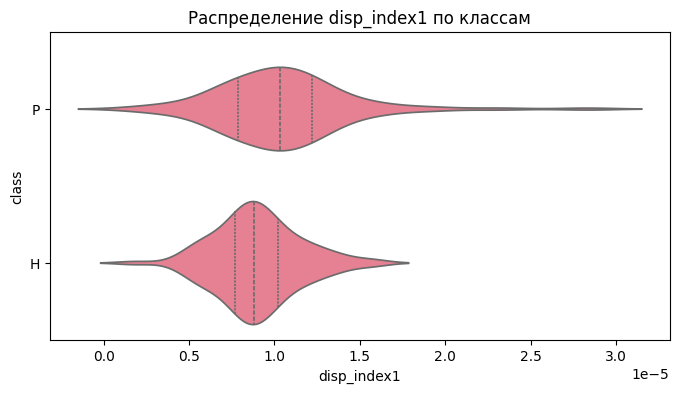

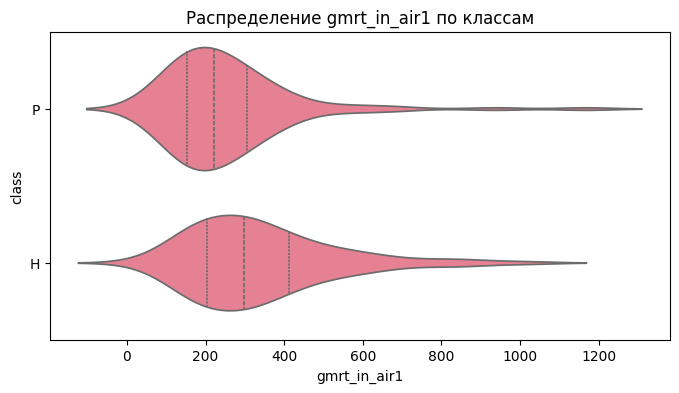

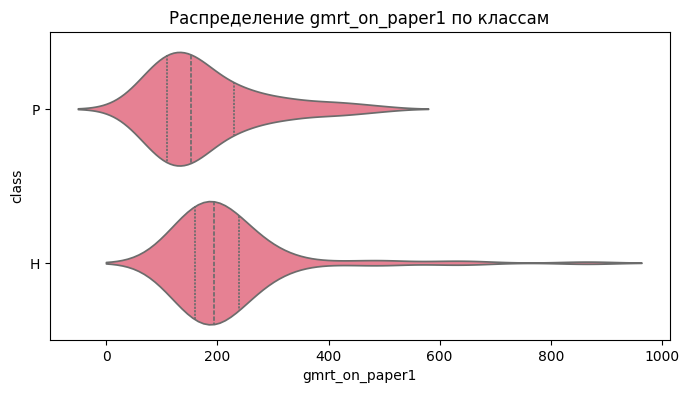

In [63]:
features_to_plot = ['air_time1', 'disp_index1', 'gmrt_in_air1', 'gmrt_on_paper1']
for feature in features_to_plot:
    if feature in df.columns:
        plt.figure(figsize=(8, 4))
        sns.violinplot(y='class', x=feature, data=df, inner='quartile')
        plt.title(f'Распределение {feature} по классам')
        plt.show()

Парный график:

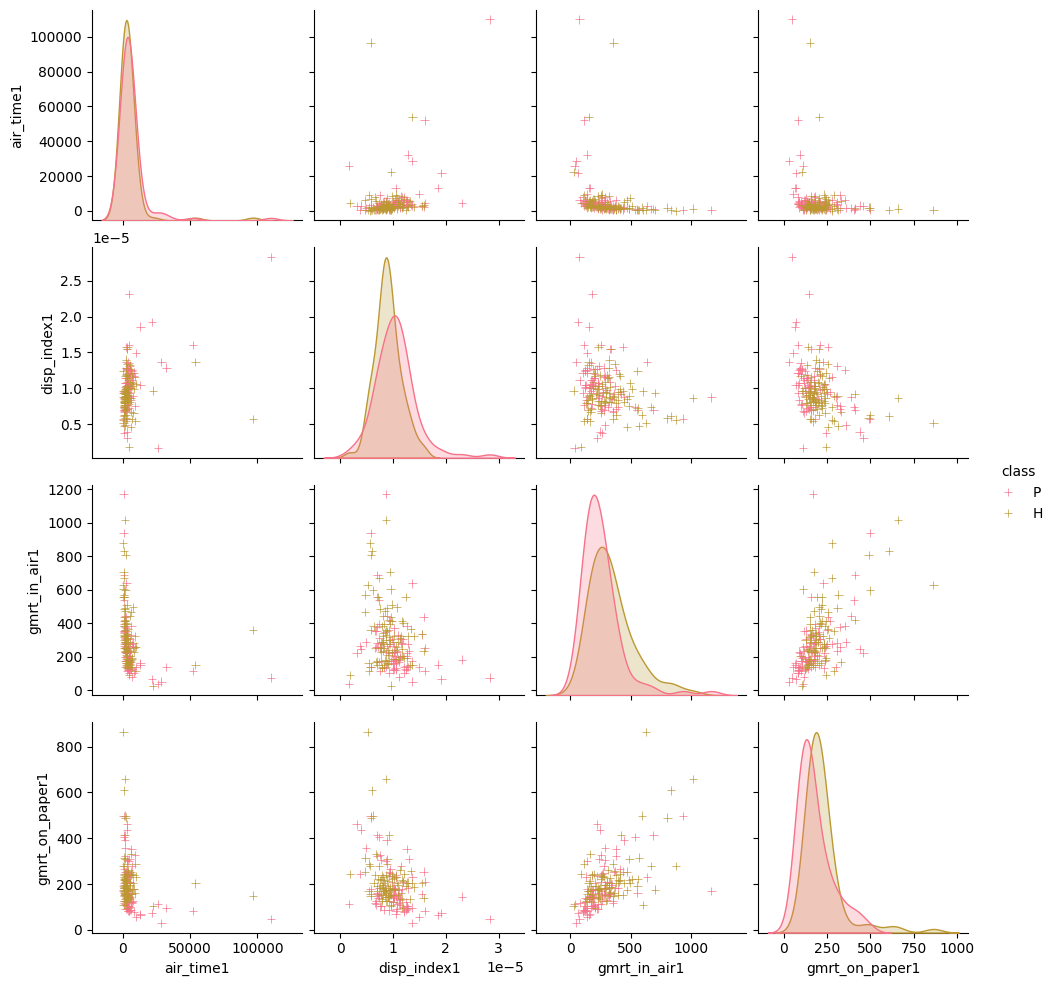

In [62]:
sns.pairplot(df, hue='class', markers='+', vars=numeric_cols[:4])
plt.show()

Тепловая карта:

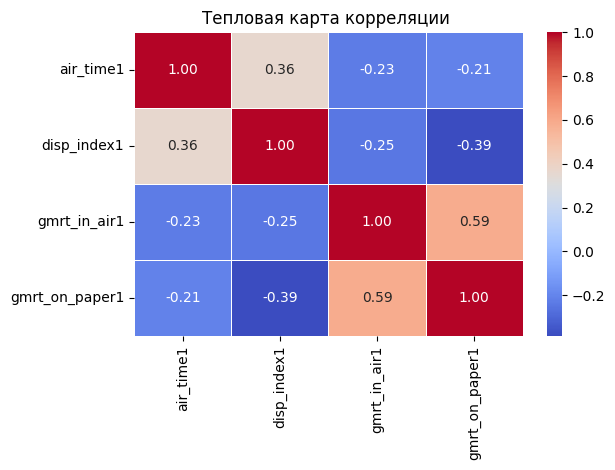

In [64]:
first_4_features = numeric_cols[:4]
corr_matrix = df[first_4_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Тепловая карта корреляции ')
plt.tight_layout()
plt.show()

3. Построение модели.

Разделение:

In [65]:
X = df.drop(['class', 'ID'], axis=1)
y = df['class']
print(f'\nX shape: {X.shape} | y shape: {y.shape} ')
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Соответствие классов:", dict(zip(le.classes_, le.transform(le.classes_))))
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, random_state=10, stratify=y_encoded)


X shape: (174, 450) | y shape: (174,) 
Соответствие классов: {'H': np.int64(0), 'P': np.int64(1)}


Обучение и выбор оптимальной модели:

In [66]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))
results = []
model_names = []
print("\nРезультаты кросс-валидации моделей:")
for name, model in models:
    kfold = StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    model_names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))


Результаты кросс-валидации моделей:
LR: 0.762169 (0.045456)
LDA: 0.813228 (0.068627)
KNN: 0.639418 (0.083107)
CART: 0.755291 (0.047802)
NB: 0.834656 (0.042378)
SVC: 0.510847 (0.014354)


Обучаем модель NB:

In [67]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred_res = nb_model.predict(X_test)
nb_probabilities = nb_model.predict_proba(X_train)
nb_accuracy = accuracy_score(y_test, nb_pred_res)
print('РЕЗУЛЬТАТЫ МОДЕЛИ NAIVE BAYES (NB)')
print(f'NB accuracy: {nb_accuracy:.4f}')
print(f'\nNB prediction (первые 30 элементов):')
print(nb_pred_res)
print('\nNB class probabilities for first 5 training samples:')
print('(вероятности для классов)')
print(nb_probabilities[:4].T)

РЕЗУЛЬТАТЫ МОДЕЛИ NAIVE BAYES (NB)
NB accuracy: 0.8857

NB prediction (первые 30 элементов):
[1 0 1 1 1 1 1 0 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0 1 0]

NB class probabilities for first 5 training samples:
(вероятности для классов)
[[1.00000000e+00 1.00000000e+00 1.00000000e+00 0.00000000e+00]
 [1.33352768e-37 1.60776227e-31 0.00000000e+00 1.00000000e+00]]


Визуализация решения:

Text(0, 0.5, 'mean_gmrt1')

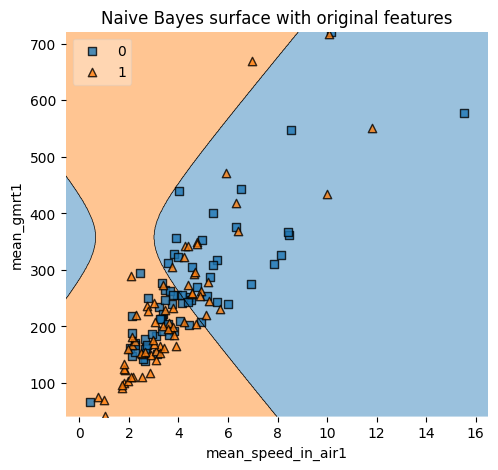

In [70]:
from mlxtend.plotting import plot_decision_regions
feature1 = 'mean_speed_in_air1'
feature2 = 'mean_gmrt1'
X_2d_nb = X_train[[feature1, feature2]].values
y_2d_nb = y_train
nb_model_2d = GaussianNB()
nb_model_2d.fit(X_2d_nb, y_2d_nb)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_regions(
    X=X_2d_nb,
    y=y_2d_nb,
    clf=nb_model_2d,
    legend=2
)
plt.title('Naive Bayes surface with original features')
plt.xlabel(feature1)
plt.ylabel(feature2)

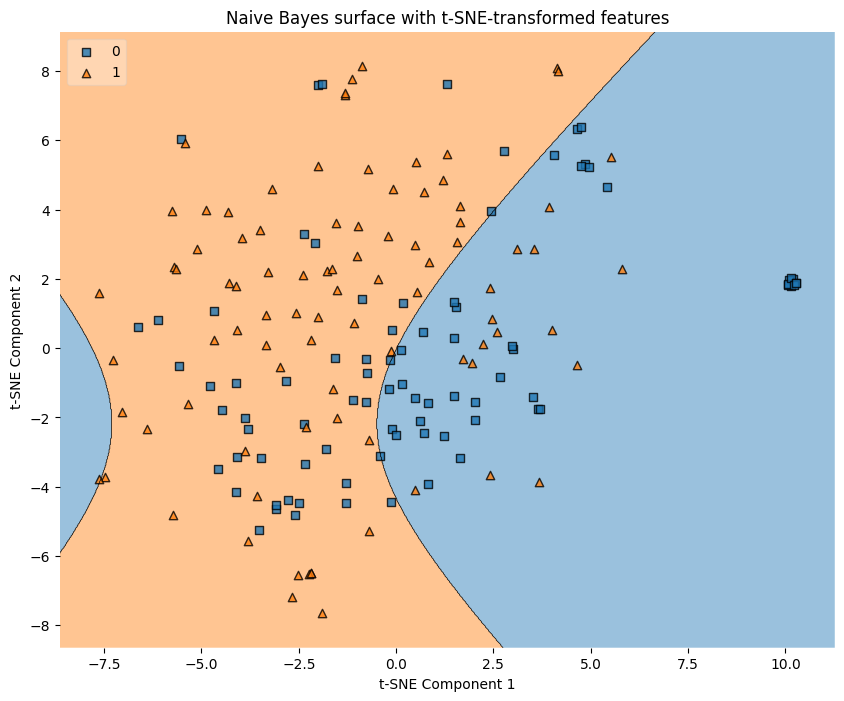

NB + t-SNE accuracy: 0.5714


In [72]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_all)
X_tsne_train, X_tsne_test, y_tsne_train, y_tsne_test = train_test_split(
    X_tsne, y_encoded, test_size=0.20, random_state=0, stratify=y_encoded
)
nb_tsne_model = GaussianNB()
nb_tsne_model.fit(X_tsne_train, y_tsne_train)
plt.figure(figsize=(10, 8))
plt.title('Naive Bayes surface with t-SNE-transformed features')
plot_decision_regions(
    X=X_tsne,
    y=y_encoded,
    clf=nb_tsne_model,
    legend=2
)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()
y_pred_tsne = nb_tsne_model.predict(X_tsne_test)
accuracy_tsne = accuracy_score(y_tsne_test, y_pred_tsne)
print(f"NB + t-SNE accuracy: {accuracy_tsne:.4f}")

In [73]:
predicted_nb = nb_model.predict(X_test)
print("Предсказания NB модели:")
print(predicted_nb)

Предсказания NB модели:
[1 0 1 1 1 1 1 0 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0 1 0]


In [74]:
from sklearn import metrics
import numpy as np
accuracy_nb = metrics.accuracy_score(y_test, predicted_nb)
recall_nb = metrics.recall_score(y_test, predicted_nb, average="weighted")
precision_nb = metrics.precision_score(y_test, predicted_nb, average="weighted")
f1_nb = metrics.f1_score(y_test, predicted_nb, average="weighted")
print("МЕТРИКИ ДЛЯ NAIVE BAYES (NB)")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Recall (weighted): {recall_nb:.4f}")
print(f"Precision (weighted): {precision_nb:.4f}")
print(f"F1-score (weighted): {f1_nb:.4f}")
print("\nДетальный отчет по классификации:")
target_names = ['P', 'H']
print(metrics.classification_report(y_test, predicted_nb, target_names=target_names))
print("\nДополнительные метрики:")
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predicted_nb)
print("Confusion Matrix:")
print(cm)
if len(np.unique(y_test)) == 2:
    from sklearn.metrics import roc_auc_score, roc_curve
    y_pred_proba = nb_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC AUC: {roc_auc:.4f}")
    from sklearn.metrics import matthews_corrcoef
    mcc = matthews_corrcoef(y_test, predicted_nb)
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")

МЕТРИКИ ДЛЯ NAIVE BAYES (NB)
Accuracy: 0.8857
Recall (weighted): 0.8857
Precision (weighted): 0.8857
F1-score (weighted): 0.8857

Детальный отчет по классификации:
              precision    recall  f1-score   support

           P       0.88      0.88      0.88        17
           H       0.89      0.89      0.89        18

    accuracy                           0.89        35
   macro avg       0.89      0.89      0.89        35
weighted avg       0.89      0.89      0.89        35


Дополнительные метрики:
Confusion Matrix:
[[15  2]
 [ 2 16]]
ROC AUC: 0.9248
Matthews Correlation Coefficient: 0.7712
